In [1]:
import pandas as pd
import numpy as np 
import os 

In [2]:
df = pd.read_csv('../data/metadata_local.csv')
df = df[(df['dataset_id'] != 'cq500_dados')]


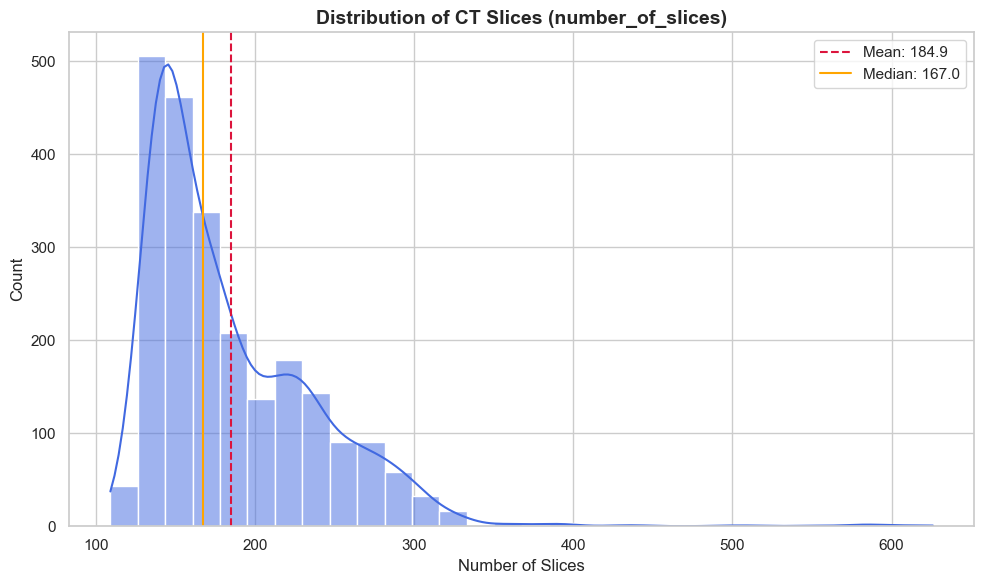

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Histogram with KDE curve
sns.histplot(
    data=df,
    x="number_of_slices",
    kde=True,
    bins=30,
    color="royalblue",
    edgecolor="white",
)

# Titles and labels
plt.title("Distribution of CT Slices (number_of_slices)", fontsize=14, weight="bold")
plt.xlabel("Number of Slices", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Optional: Add median and mean indicator lines
mean_val = df["number_of_slices"].mean()
median_val = df["number_of_slices"].median()

plt.axvline(mean_val, color="crimson", linestyle="--", label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color="orange", linestyle="-", label=f"Median: {median_val:.1f}")
plt.legend()

plt.tight_layout()
plt.show()

In [4]:



df["selected_local"] = (df["number_of_slices"] > 200) | (
    df["dataset_id"] == "physionet"
)




In [17]:
df_local = df[df["selected_local"] == True]

In [ ]:
save_csv.loc[save_csv['Achados'] == 'Normal', 'number_of_slices'].sum()

## Physionet metadata

In [20]:
df_local["pixel_spacing_xy"] = df_local["pixel_spacing_xy"].astype("object")
df_local["pixel_spacing_z"] = df_local["pixel_spacing_z"].astype("object")

In [22]:
import nibabel as nib

def extract_nifti_metadata(file_path):
    """Reads NIfTI metadata and returns a dictionary of relevant CT parameters."""
    if not file_path or pd.isna(file_path):
        return {}

    try:
        img = nib.load(file_path)
        header = img.header

        # 1. Image dimensions & slices
        shape = img.shape
        num_slices = shape[2] if len(shape) >= 3 else None

        # 2. Voxel/Pixel Spacing
        zooms = header.get_zooms()
        pixel_spacing_xy = float(zooms[0]) if len(zooms) >= 1 else None

        # Slice thickness from header (if explicitly defined and > 0)
        raw_thickness = float(header.get("slice_thickness", 0.0))
        slice_thickness = raw_thickness if raw_thickness > 0 else np.nan

        # Assign z-spacing, falling back to slice thickness if zoom along Z is missing
        z_from_zoom = float(zooms[2]) if len(zooms) >= 3 else None
        pixel_spacing_z = (
            z_from_zoom
            if z_from_zoom is not None
            else (slice_thickness if not np.isnan(slice_thickness) else np.nan)
        )

        # 3. Rescale slope and intercept
        slope = float(header.get("scl_slope", 1.0))
        intercept = float(header.get("scl_inter", 0.0))

        if np.isnan(slope) or slope == 0:
            slope = 1.0
        if np.isnan(intercept):
            intercept = 0.0

        # 4. Machine/Scanner info set to NaN
        machine = np.nan

        return {
            "machine": machine,
            "number_of_slices": num_slices,
            "slice_thickness": slice_thickness,
            "pixel_spacing_xy": pixel_spacing_xy,
            "pixel_spacing_z": pixel_spacing_z,
            "rescale_slope": slope,
            "rescale_intercept": intercept,
        }

    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return {}


# --- Execution on DataFrame ---

# Filter index for physionet rows
physio_idx = df_local[df_local["dataset_id"] == "physionet"].index

# Extract metadata for each physionet row
metadata_records = [
    extract_nifti_metadata(path)
    for path in df_local.loc[physio_idx, "local_Path"]
]
meta_df = pd.DataFrame(metadata_records, index=physio_idx)

# Assign the metadata back to df_local
cols_to_update = [
    "machine",
    "number_of_slices",
    "slice_thickness",
    "pixel_spacing_xy",
    "pixel_spacing_z",
    "rescale_slope",
    "rescale_intercept",
]

# 1. Cast existing target columns in df_local to object to avoid strict dtype enforcement
for col in cols_to_update:
    if col in df_local.columns:
        df_local[col] = df_local[col].astype("object")

# 2. Assign the metadata directly
for col in cols_to_update:
    if col in meta_df.columns:
        df_local.loc[physio_idx, col] = meta_df[col].values

# Check sample results
print(df_local.loc[physio_idx, ["patient_id"] + cols_to_update].head())


     patient_id machine number_of_slices slice_thickness pixel_spacing_xy  \
2324         49     NaN               39             NaN         0.412109   
2325         50     NaN               32             NaN         0.351562   
2326         51     NaN               46             NaN         0.412109   
2327         52     NaN               35             NaN         0.390625   
2328         53     NaN               35             NaN         0.472656   

     pixel_spacing_z rescale_slope rescale_intercept  
2324             5.0           1.0               0.0  
2325             5.0           1.0               0.0  
2326             5.0           1.0               0.0  
2327             5.0           1.0               0.0  
2328             5.0           1.0               0.0  


In [24]:
df_local.to_csv('../data/sampled_metadata_aux.csv', index = False)

In [ ]:
save_csv.to_csv('../data/sampled_metadata.csv', index = False)